In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
df=pd.read_csv("/content/TCGA_GBM_LGG_Mutations_all.csv")
df

,Grade,Project,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,TCGA-LGG,TCGA-DU-8164,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-LGG,TCGA-QH-A6CY,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,TCGA-LGG,TCGA-HW-A5KM,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-LGG,TCGA-E1-A7YE,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,TCGA-LGG,TCGA-S9-A6WG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,GBM,TCGA-GBM,TCGA-19-5959,Female,77 years 325 days,Glioblastoma,white,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
858,GBM,TCGA-GBM,TCGA-16-0846,Male,85 years 65 days,Glioblastoma,white,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
859,GBM,TCGA-GBM,TCGA-28-1746,Female,77 years 178 days,Glioblastoma,white,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
860,GBM,TCGA-GBM,TCGA-32-2491,Male,63 years 121 days,Glioblastoma,white,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [ ]:
df.shape

(862, 27)

In [ ]:
print("Informations sur le dataset:", df.info())
print("="*80)
# Informations générales sur le dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Grade              862 non-null    object
 1   Project            862 non-null    object
 2   Case_ID            862 non-null    object
 3   Gender             862 non-null    object
 4   Age_at_diagnosis   862 non-null    object
 5   Primary_Diagnosis  862 non-null    object
 6   Race               862 non-null    object
 7   IDH1               862 non-null    object
 8   TP53               862 non-null    object
 9   ATRX               862 non-null    object
 10  PTEN               862 non-null    object
 11  EGFR               862 non-null    object
 12  CIC                862 non-null    object
 13  MUC16              862 non-null    object
 14  PIK3CA             862 non-null    object
 15  NF1                862 non-null    object
 16  PIK3R1             862 non-null    object
 1

In [ ]:
df.isnull().sum()

,0
Grade,0
Project,0
Case_ID,0
Gender,0
Age_at_diagnosis,0
Primary_Diagnosis,0
Race,0
IDH1,0
TP53,0
ATRX,0


In [ ]:
df['Age_at_diagnosis'].unique()

array(['51 years 108 days', '38 years 261 days', '35 years 62 days',
       '32 years 283 days', '31 years 187 days', '33 years 78 days',
       '35 years 68 days', '44 years 239 days', '33 years 350 days',
       '87 years', '51 years 328 days', '54 years 95 days',
       '52 years 214 days', '47 years 123 days', '34 years 132 days',
       '40 years 192 days', '53 years 352 days', '41 years 70 days',
       '43 years 161 days', '37 years 159 days', '47 years 173 days',
       '31 years 8 days', '25 years 191 days', '66 years 305 days',
       '56 years 250 days', '35 years 362 days', '51 years 363 days',
       '37 years 32 days', '54 years 183 days', '32 years 76 days',
       '65 years 28 days', '43 years 131 days', '51 years 59 days',
       '43 years 221 days', '25 years 214 days', '45 years 24 days',
       '50 years 153 days', '27 years 166 days', '53 years 252 days',
       '46 years 144 days', '24 years 239 days', '--', '34 years 70 days',
       '29 years 198 days', '45 year

In [ ]:
def age_to_years(age_str):
    if age_str == "--":
        return 0  # Or np.nan if you prefer to represent missing data

    # Ensure it's treated as string before splitting to prevent errors on unexpected types
    age_str = str(age_str)

    parts = age_str.split(' ')
    years = int(parts[0])

    days = 0
    # Check if there are enough parts for 'days' and if 'days' token is present
    if len(parts) >= 4 and parts[3].lower() == 'days':
        days = int(parts[2])

    return years + days/365



In [ ]:
df['Age_at_diagnosis']

,Age_at_diagnosis
0,51 years 108 days
1,38 years 261 days
2,35 years 62 days
3,32 years 283 days
4,31 years 187 days
...,...
857,77 years 325 days
858,85 years 65 days
859,77 years 178 days
860,63 years 121 days


In [ ]:
import numpy as np
import pandas as pd

# To fix the AttributeError, we need to ensure the 'Age_at_diagnosis' column is in its original string format.
# We will re-read the CSV to get the original 'Age_at_diagnosis' column before applying the conversion.
original_data = pd.read_csv("/content/TCGA_GBM_LGG_Mutations_all.csv")
df['Age_at_diagnosis'] = original_data['Age_at_diagnosis'] # Restore original string column

df['Age_at_diagnosis'] = df['Age_at_diagnosis'].apply(age_to_years)
df['Age_at_diagnosis']

,Age_at_diagnosis
0,51.295890
1,38.715068
2,35.169863
3,32.775342
4,31.512329
...,...
857,77.890411
858,85.178082
859,77.487671
860,63.331507


In [ ]:

df['Age_at_diagnosis'] = df['Age_at_diagnosis'].astype(int)
df['Age_at_diagnosis']

,Age_at_diagnosis
0,51
1,38
2,35
3,32
4,31
...,...
857,77
858,85
859,77
860,63


In [ ]:
for col in df.columns:
  numerical_features=["Age_at_diagnosis"]
  if col not in numerical_features:
    print(col,df[col].unique())
    print("-"*70)

Grade ['LGG' 'GBM']
----------------------------------------------------------------------
Project ['TCGA-LGG' 'TCGA-GBM']
----------------------------------------------------------------------
Case_ID ['TCGA-DU-8164' 'TCGA-QH-A6CY' 'TCGA-HW-A5KM' 'TCGA-E1-A7YE'
 'TCGA-S9-A6WG' 'TCGA-DB-A4X9' 'TCGA-P5-A5F4' 'TCGA-FG-A4MY'
 'TCGA-HT-A5R5' 'TCGA-DU-A76K' 'TCGA-QH-A6CV' 'TCGA-FG-5962'
 'TCGA-DU-6402' 'TCGA-DB-A75M' 'TCGA-DB-A4XG' 'TCGA-DU-5851'
 'TCGA-DB-A4XH' 'TCGA-HT-7874' 'TCGA-DH-A66D' 'TCGA-DU-5871'
 'TCGA-FG-A60J' 'TCGA-E1-A7Z3' 'TCGA-DU-7011' 'TCGA-VW-A8FI'
 'TCGA-DU-A7TB' 'TCGA-HT-7856' 'TCGA-TQ-A7RU' 'TCGA-HW-7486'
 'TCGA-DU-6399' 'TCGA-DU-A7TA' 'TCGA-HT-A5RA' 'TCGA-DB-5280'
 'TCGA-DU-6405' 'TCGA-S9-A7J1' 'TCGA-S9-A7J2' 'TCGA-HW-7495'
 'TCGA-FG-A710' 'TCGA-P5-A5ET' 'TCGA-DU-7300' 'TCGA-DU-A5TY'
 'TCGA-VM-A8CH' 'TCGA-R8-A6YH' 'TCGA-S9-A6WE' 'TCGA-HT-7681'
 'TCGA-KT-A7W1' 'TCGA-FG-5964' 'TCGA-S9-A6TX' 'TCGA-P5-A5F2'
 'TCGA-DU-5874' 'TCGA-DU-A5TT' 'TCGA-CS-5396' 'TCGA-DU-7302'
 'TCG

Applying Label Encoder for Gender

In [ ]:
df['Gender'] = df['Gender'].replace('--', np.nan)
df = df.dropna(subset=['Gender'])

label_encoder=LabelEncoder()

df['Gender']=label_encoder.fit_transform(df['Gender'])
df['Gender']

/tmp/ipython-input-1465995275.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender']=label_encoder.fit_transform(df['Gender'])


,Gender
0,1
1,1
2,1
3,0
4,1
...,...
857,0
858,1
859,0
860,1


In [ ]:
df = df.drop('Primary_Diagnosis', axis=1)


In [ ]:
df['Race'].value_counts(dropna=False)


,count
Race,
white,766
black or african american,59
not reported,18
asian,14
american indian or alaska native,1


In [ ]:
df=df[df['Race'] !='not reported']
df = pd.get_dummies(df, columns=['Race'], drop_first=True)


In [ ]:
df

,Grade,Project,Case_ID,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,...,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Race_asian,Race_black or african american,Race_white
0,LGG,TCGA-LGG,TCGA-DU-8164,1,51,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
1,LGG,TCGA-LGG,TCGA-QH-A6CY,1,38,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
2,LGG,TCGA-LGG,TCGA-HW-A5KM,1,35,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
3,LGG,TCGA-LGG,TCGA-E1-A7YE,0,32,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,False,False,True
4,LGG,TCGA-LGG,TCGA-S9-A6WG,1,31,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,GBM,TCGA-GBM,TCGA-19-5959,0,77,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
858,GBM,TCGA-GBM,TCGA-16-0846,1,85,NOT_MUTATED,MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
859,GBM,TCGA-GBM,TCGA-28-1746,0,77,NOT_MUTATED,MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True
860,GBM,TCGA-GBM,TCGA-32-2491,1,63,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,False,False,True


In [ ]:
df = df.drop(['Case_ID', 'Project'], axis=1)


In [ ]:
mutation_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                 'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3','SMARCA4',
                 'GRIN2A','IDH2','FAT4','PDGFRA']

for col in mutation_cols:
    df[col] = df[col].map({'MUTATED': 1, 'NOT_MUTATED': 0})


In [ ]:
for col in df.columns:
  numerical_features=["Age_at_diagnosis"]
  if col not in numerical_features:
    print(col,df[col].unique())
    print("-"*70)

Grade ['LGG' 'GBM']
----------------------------------------------------------------------
Gender [1 0]
----------------------------------------------------------------------
IDH1 [1 0]
----------------------------------------------------------------------
TP53 [0 1]
----------------------------------------------------------------------
ATRX [0 1]
----------------------------------------------------------------------
PTEN [0 1]
----------------------------------------------------------------------
EGFR [0 1]
----------------------------------------------------------------------
CIC [0 1]
----------------------------------------------------------------------
MUC16 [0 1]
----------------------------------------------------------------------
PIK3CA [1 0]
----------------------------------------------------------------------
NF1 [0 1]
----------------------------------------------------------------------
PIK3R1 [0 1]
----------------------------------------------------------------------
FU

In [ ]:
y = df['Grade'].map({'LGG': 0, 'GBM': 1})
df['Grade'] = y



In [ ]:
y

,Grade
0,0
1,0
2,0
3,0
4,0
...,...
857,1
858,1
859,1
860,1


In [ ]:
print(df.dtypes)
print(df.head())


Grade                             int64
Gender                            int64
Age_at_diagnosis                  int64
IDH1                              int64
TP53                              int64
ATRX                              int64
PTEN                              int64
EGFR                              int64
CIC                               int64
MUC16                             int64
PIK3CA                            int64
NF1                               int64
PIK3R1                            int64
FUBP1                             int64
RB1                               int64
NOTCH1                            int64
BCOR                              int64
CSMD3                             int64
SMARCA4                           int64
GRIN2A                            int64
IDH2                              int64
FAT4                              int64
PDGFRA                            int64
Race_asian                         bool
Race_black or african american     bool


Distribution de la variable cible 'Exited':

Nombre de patients ayant LGG (0): 488 (58.10%)
Nombre de pateints ayant GBM (1): 352 (41.90%)


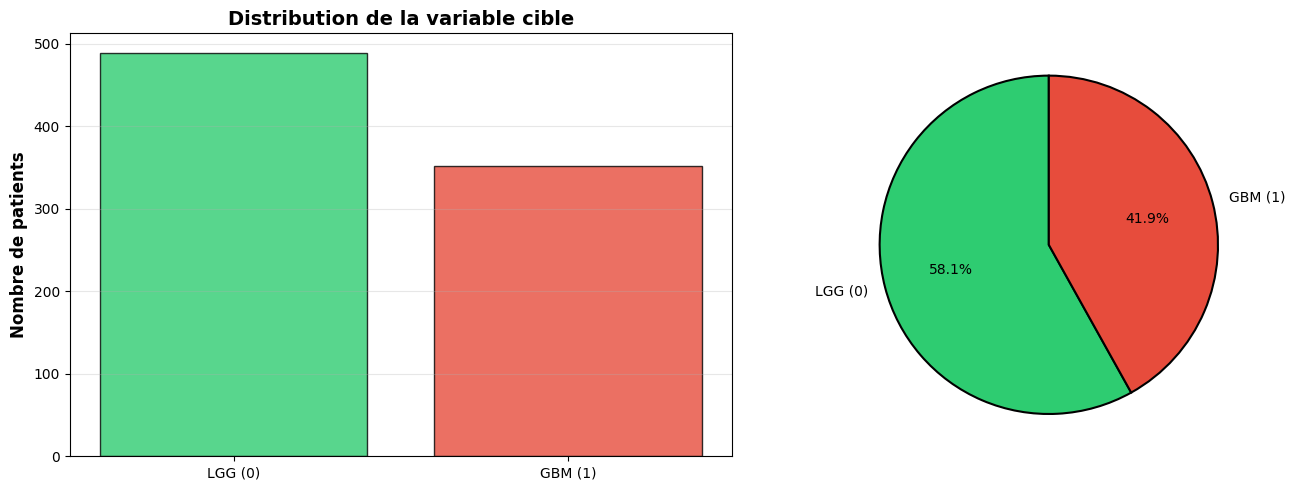

In [ ]:
import matplotlib.pyplot as plt

# Distribution de la variable cible
target_counts=y.value_counts()
target_percentage=y.value_counts(normalize=True)*100


print("Distribution de la variable cible 'Exited':" , )
print("="*80)
print(f"\nNombre de patients ayant LGG (0): {target_counts[0]} ({target_percentage[0]:.2f}%)")
print(f"Nombre de pateints ayant GBM (1): {target_counts[1]} ({target_percentage[1]:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['LGG (0)', 'GBM (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Nombre de patients', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=['LGG (0)', 'GBM (1)'],
           autopct='%1.1f%%', colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})


plt.tight_layout()
plt.show()

In [ ]:
df

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Race_asian,Race_black or african american,Race_white
0,0,1,51,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
1,0,1,38,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,False,False,True
2,0,1,35,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
3,0,0,32,1,1,1,0,0,0,1,...,0,0,0,0,0,1,0,False,False,True
4,0,1,31,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,1,0,77,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
858,1,1,85,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
859,1,0,77,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
860,1,1,63,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,False,False,True


IndexError: index 9 is out of bounds for axis 0 with size 9

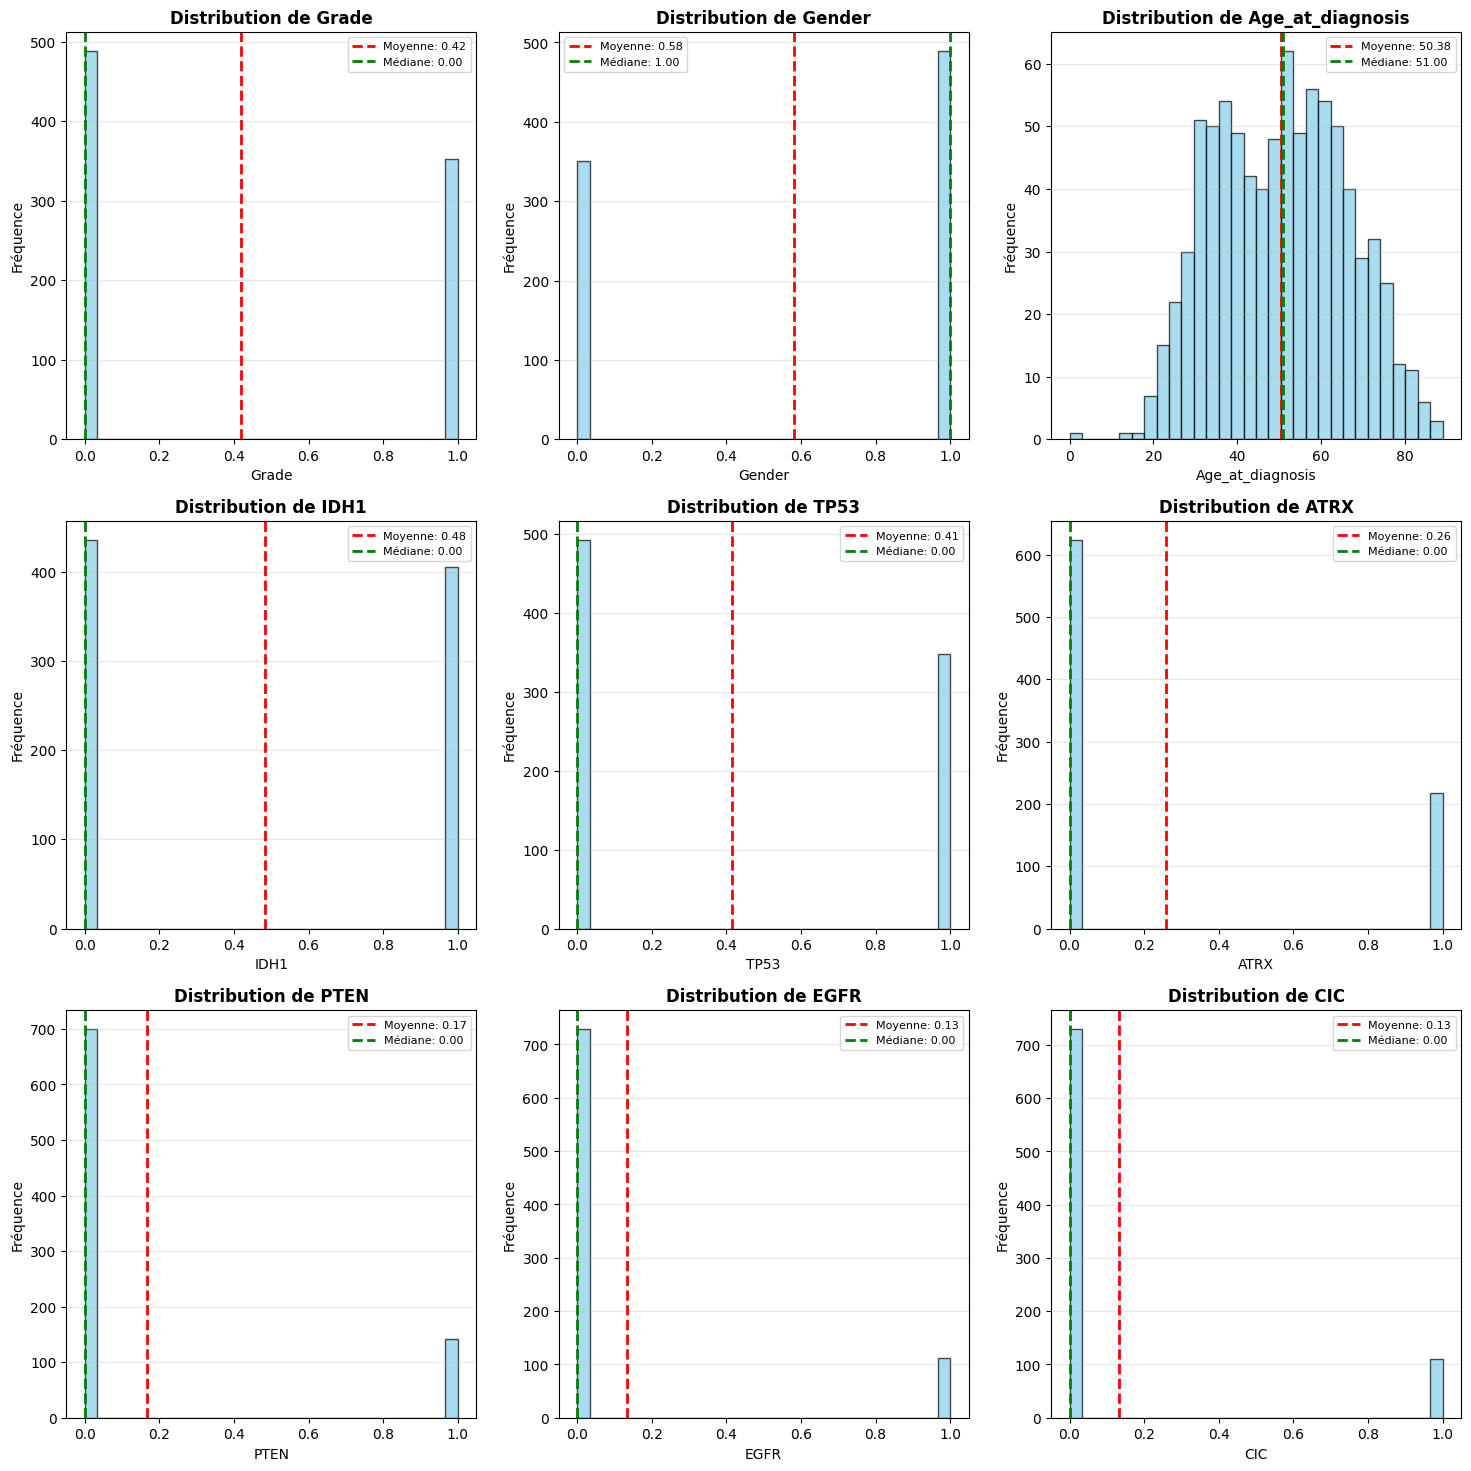

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', bool]).columns


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='skyblue',
                   alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Fréquence', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

    # Statistiques
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--',
                      linewidth=2, label=f'Moyenne: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--',
                      linewidth=2, label=f'Médiane: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1870818189.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1870818189.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1870818189.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1870818189.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([plot_data_0,
/tmp/ipython-input-1

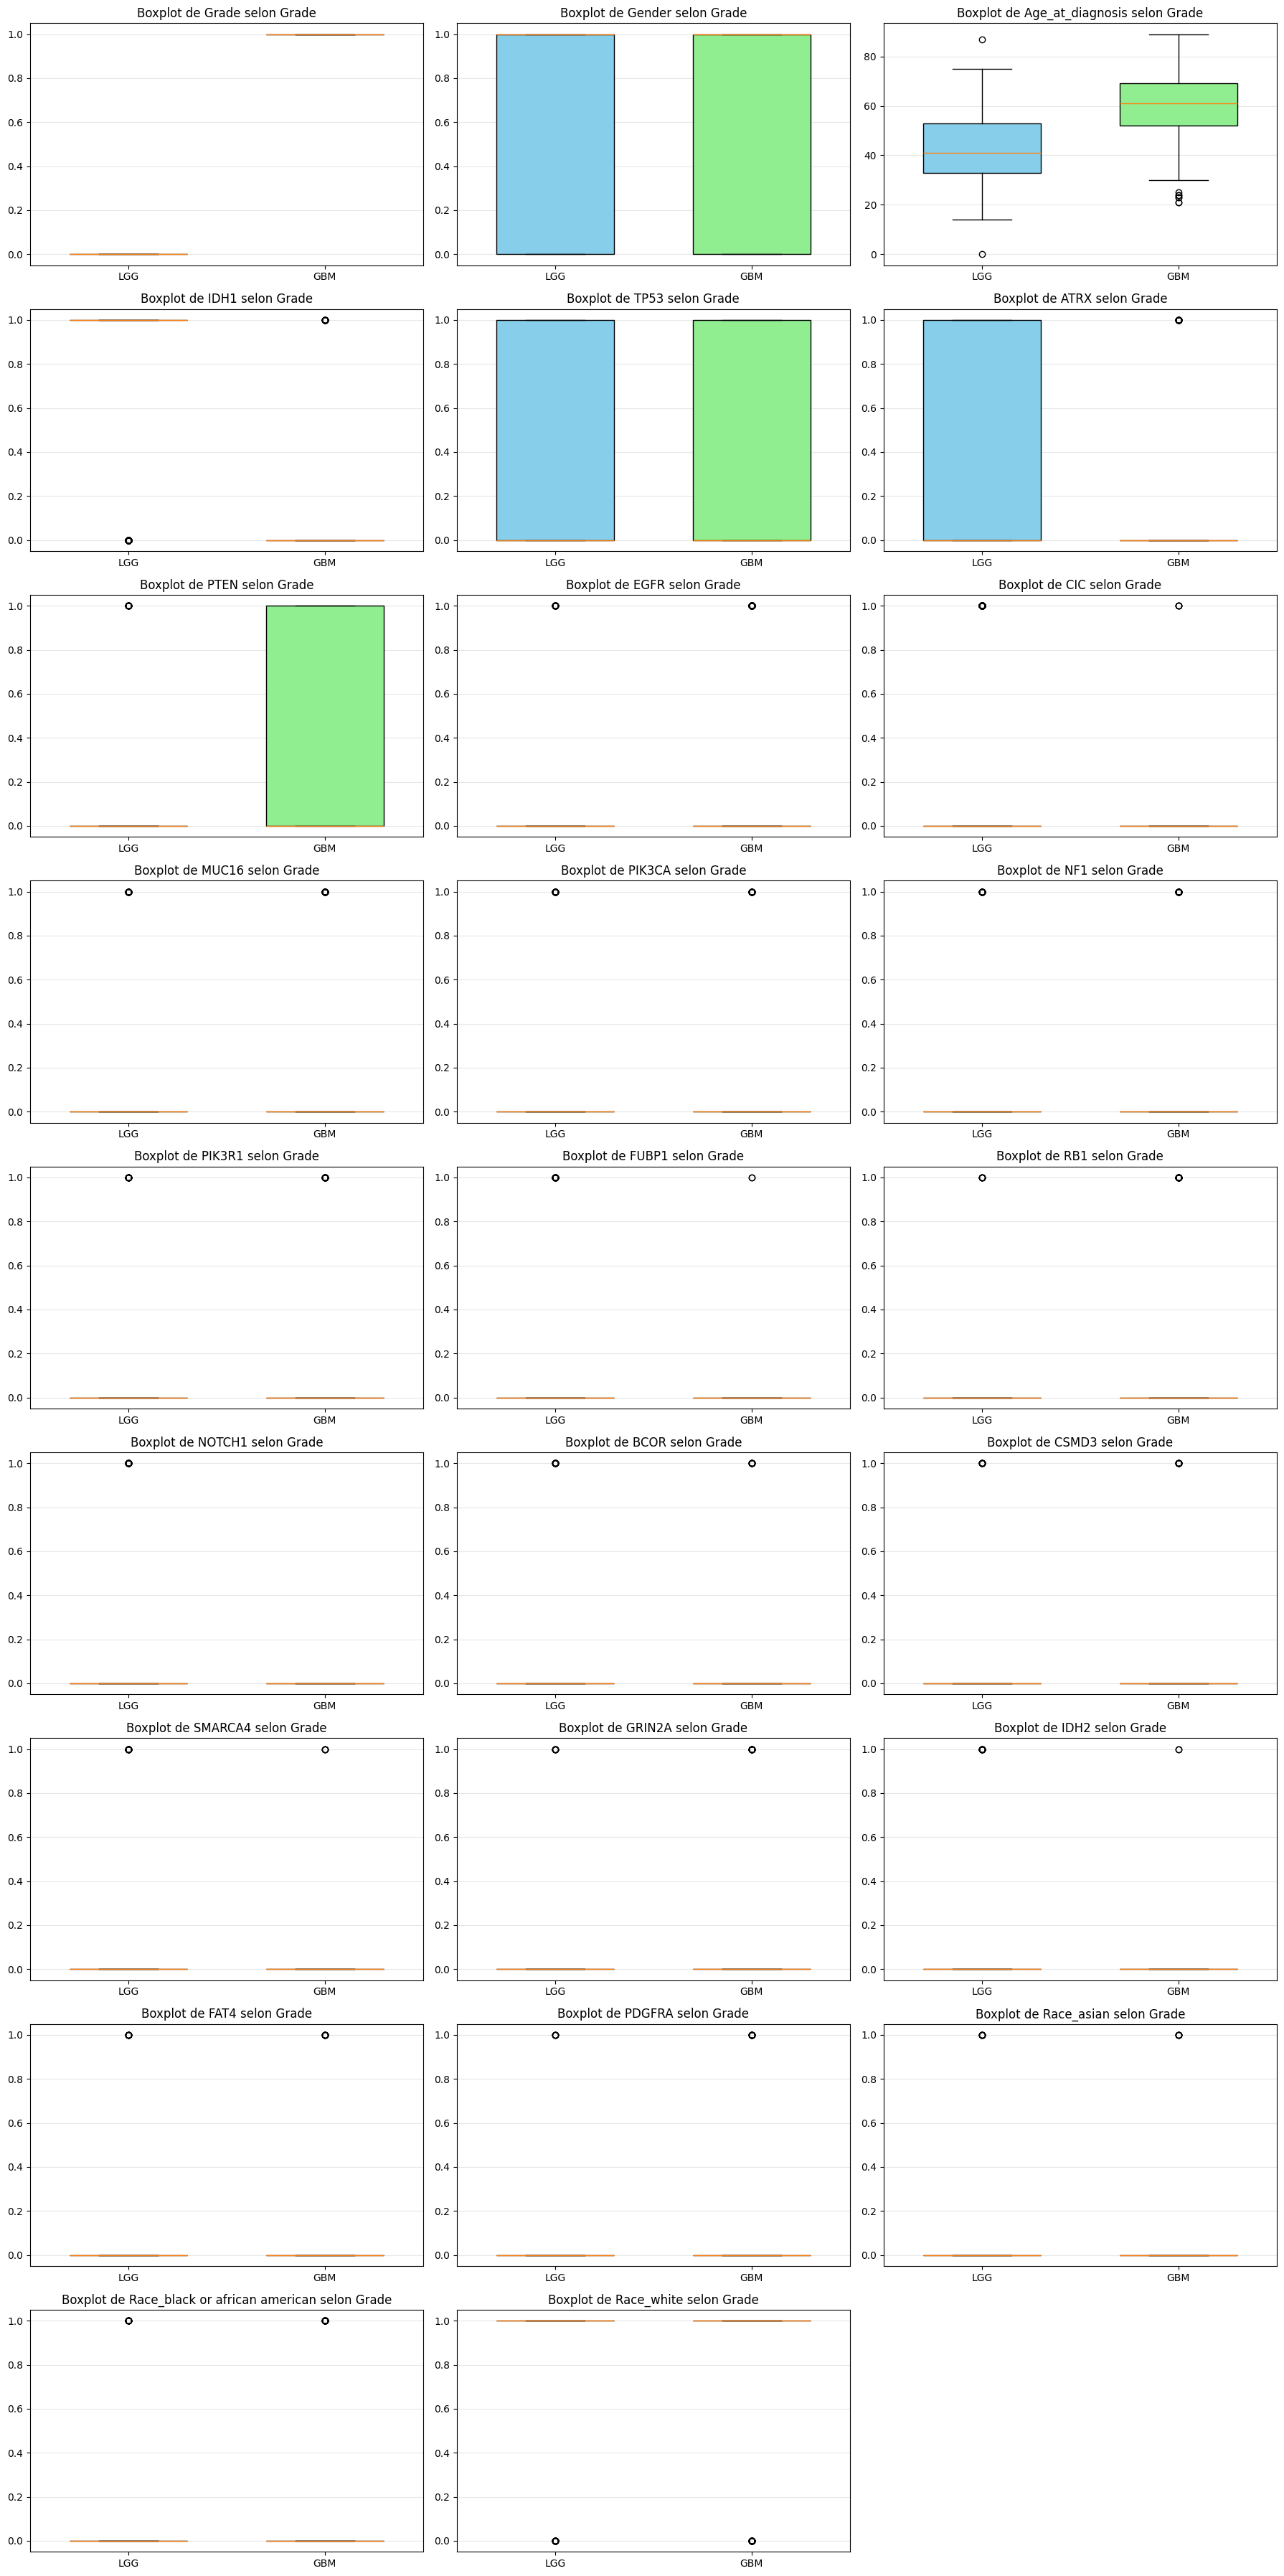

In [ ]:
import math
import matplotlib.pyplot as plt

# Get numerical and boolean columns
numerical_cols = df.select_dtypes(include=['int64', bool]).columns

n_cols = 3
n_rows = math.ceil(len(numerical_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Convert boolean columns to int (0 or 1) for plotting if necessary
    plot_data_0 = df[y==0][col].dropna()
    plot_data_1 = df[y==1][col].dropna()

    if plot_data_0.dtype == bool:
        plot_data_0 = plot_data_0.astype(int)
    if plot_data_1.dtype == bool:
        plot_data_1 = plot_data_1.astype(int)

    bp = axes[idx].boxplot([plot_data_0,
                            plot_data_1],
                           labels=['LGG', 'GBM'],
                           patch_artist=True,
                           widths=0.6)

    # Couleurs
    colors = ['skyblue', 'lightgreen']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    axes[idx].set_title(f'Boxplot de {col} selon Grade', fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)

# Supprimer les axes vides si nécessaire
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:

df

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Race_asian,Race_black or african american,Race_white
0,0,1,51,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
1,0,1,38,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,False,False,True
2,0,1,35,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
3,0,0,32,1,1,1,0,0,0,1,...,0,0,0,0,0,1,0,False,False,True
4,0,1,31,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,1,0,77,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
858,1,1,85,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
859,1,0,77,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,False,False,True
860,1,1,63,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,False,False,True


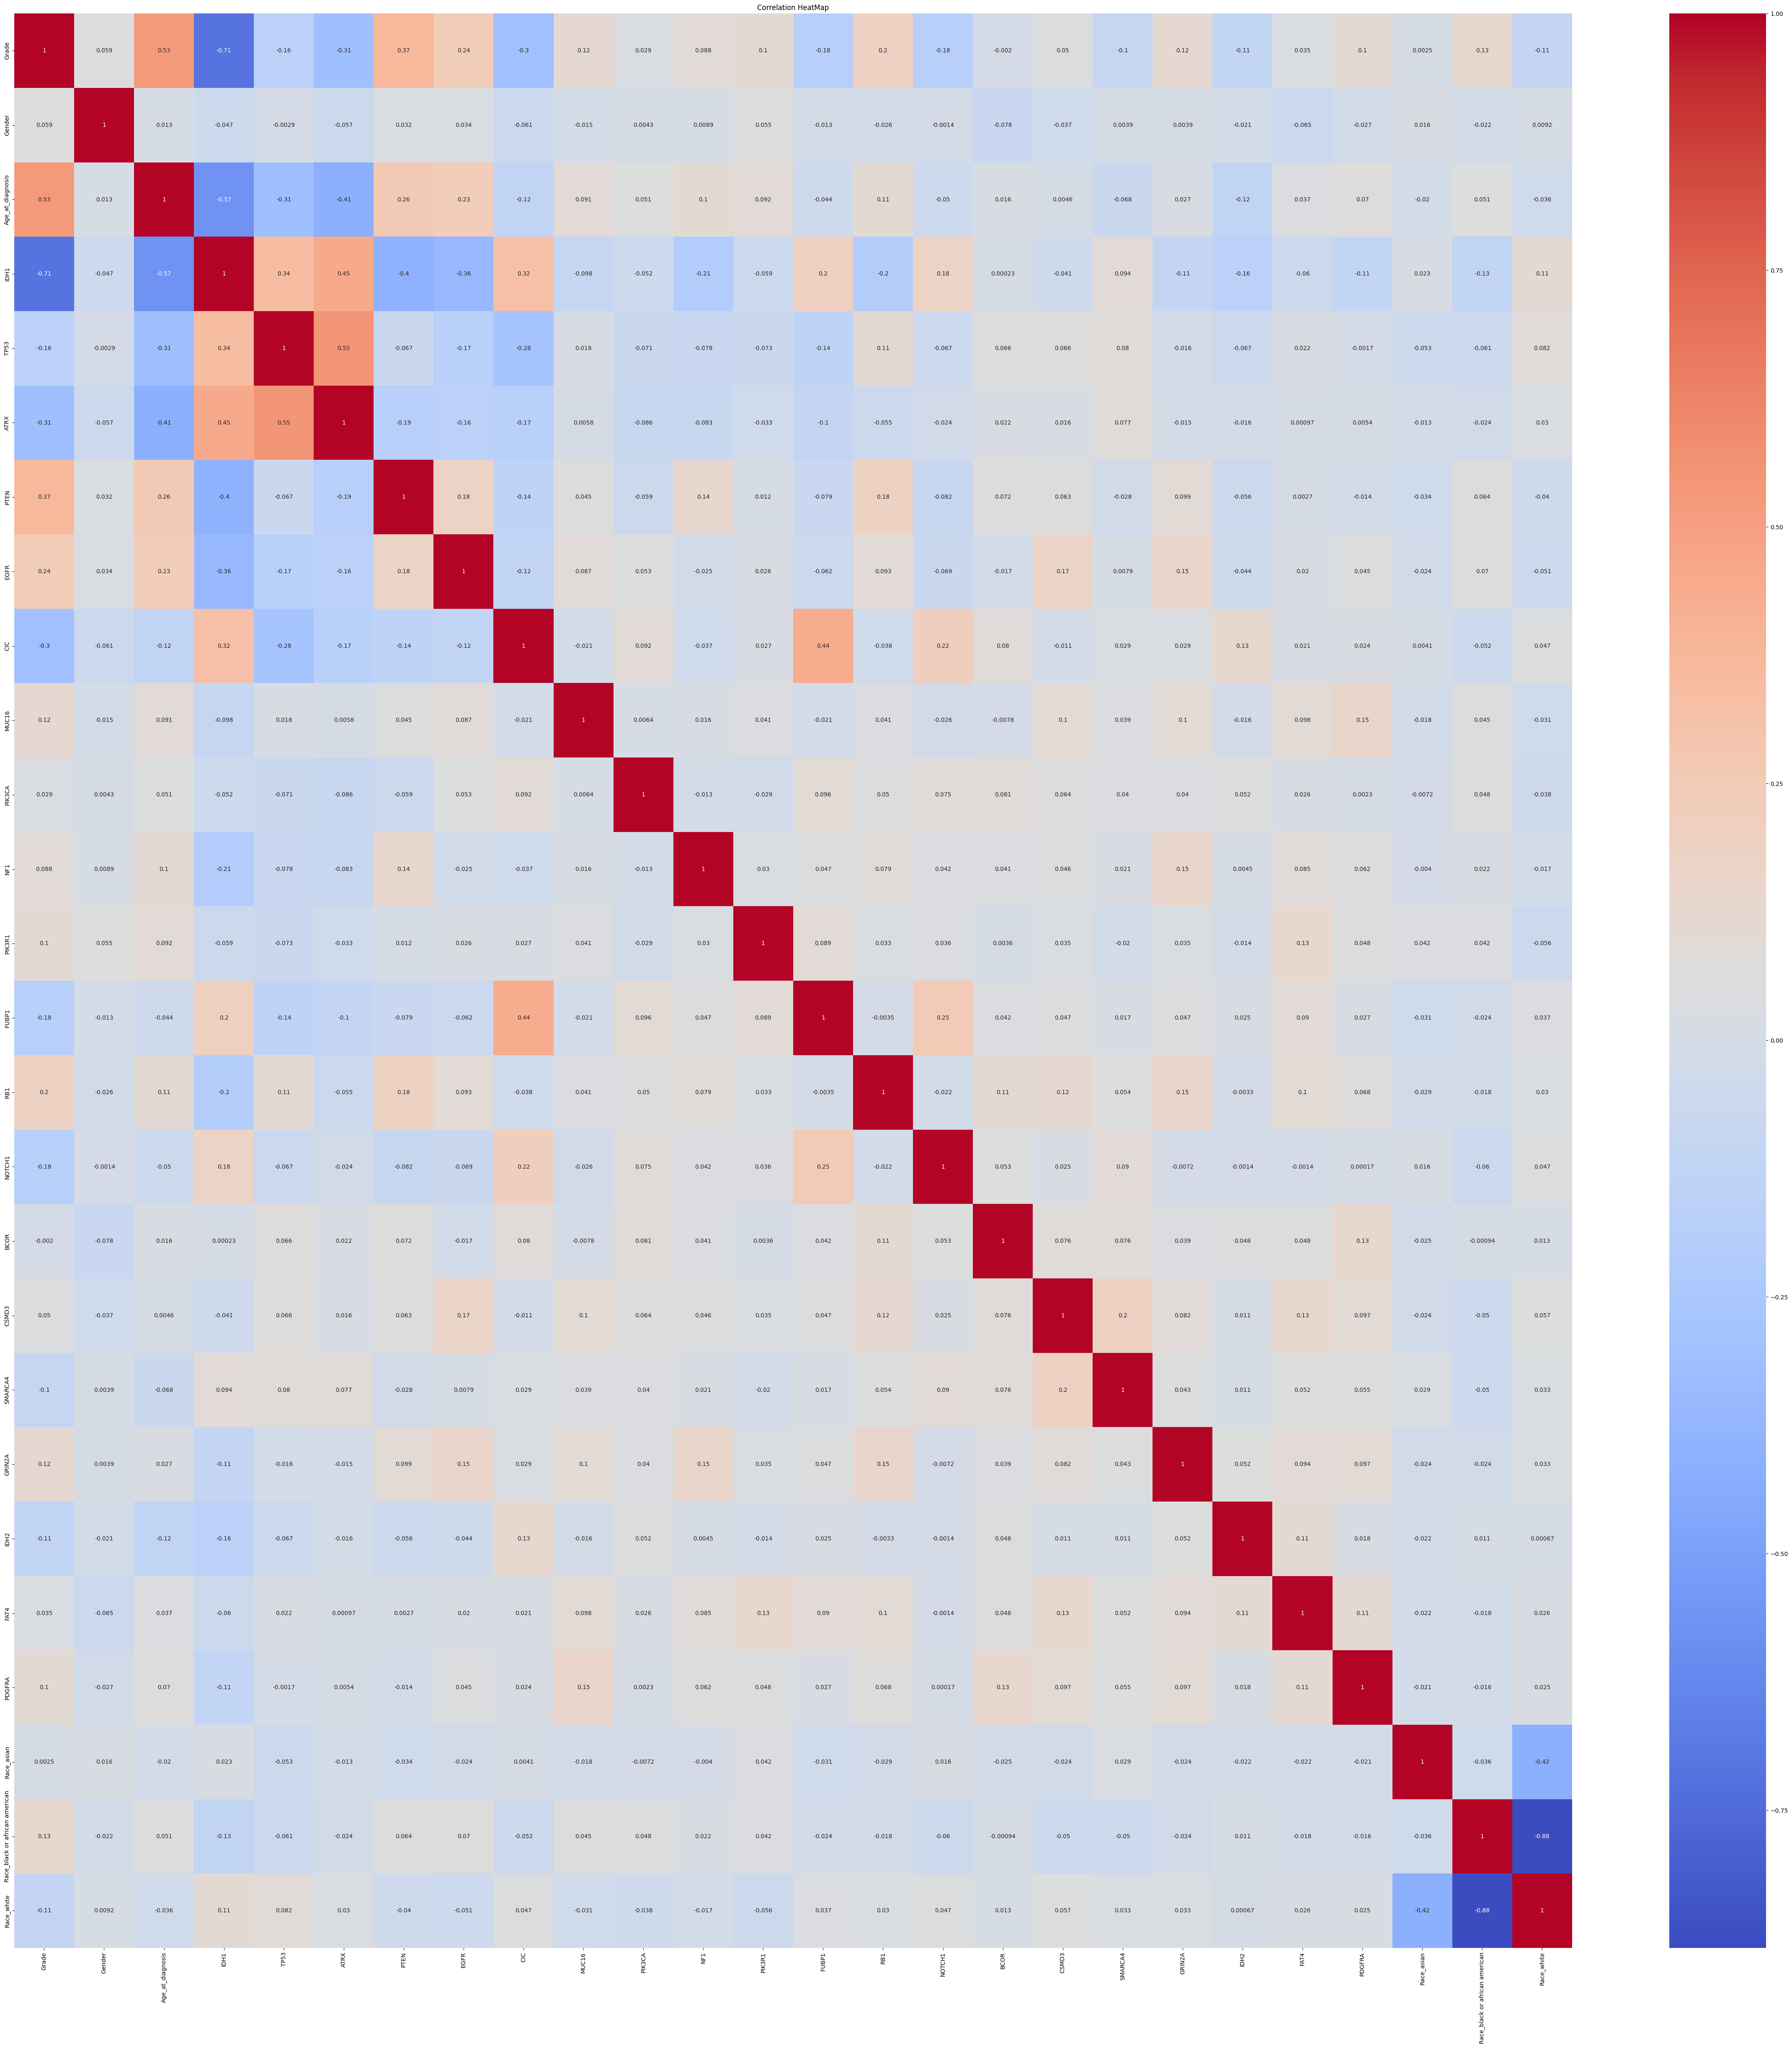

In [ ]:
import matplotlib.pyplot as plt
!pip install --upgrade seaborn # Ensure seaborn is installed and up-to-date
import seaborn as sns

plt.figure(figsize=(60,60))
sns.heatmap(df.corr(),annot =True , cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.show()

In [ ]:
df.describe()

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
count,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,...,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000
mean,0.419048,0.582143,50.383333,0.482143,0.414286,0.258333,0.167857,0.133333,0.132143,0.116667,...,0.053571,0.047619,0.045238,0.034524,0.032143,0.032143,0.032143,0.027381,0.027381,0.026190
std,0.493697,0.493500,15.799118,0.499979,0.492892,0.437979,0.373962,0.340137,0.338848,0.321214,...,0.225304,0.213086,0.207950,0.182679,0.176484,0.176484,0.176484,0.163288,0.163288,0.159797
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,62.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
X = df.drop('Grade', axis=1)
y = df['Grade']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Exemple avec ton dataset
# Supposons que df est ton DataFrame et 'Age_at_diagnosis' est la colonne à normaliser
scaler = MinMaxScaler()  # crée l'objet scaler

# On reshape la colonne car MinMaxScaler attend un 2D array
X_train['Age_at_diagnosis'] = scaler.fit_transform(X_train[['Age_at_diagnosis']])
X_test['Age_at_diagnosis'] = scaler.transform(X_test[['Age_at_diagnosis']])



In [ ]:
X_train['Age_at_diagnosis']

,Age_at_diagnosis
178,0.325843
463,0.483146
722,0.606742
441,0.584270
6,0.393258
...,...
624,0.876404
411,0.292135
773,0.651685
39,0.516854


In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Fonction pour évaluer les performances d'un modèle
    """
    # Prédictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probabilités pour ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    # Métriques
    results = {
        'Modèle': name,
        'Accuracy Train': accuracy_score(y_train, y_pred_train),
        'Accuracy Test': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc
    }

    # Affichage
    print(f"\n{'='*80}")
    print(f"MODÈLE: {name}")
    print(f"{'='*80}")

    for metric, value in results.items():
        if metric != 'Modèle':
            if value is not None:
                print(f"{metric:20s}: {value:.4f}")
            else:
                print(f"{metric:20s}: N/A")

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_test)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['LGG', 'GBM'],
                yticklabels=['LGG', 'GBM'])
    plt.title(f'Matrice de Confusion - {name}', fontsize=14, fontweight='bold')
    plt.ylabel('Vraie Classe', fontsize=12)
    plt.xlabel('Classe Prédite', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Rapport de classification
    print(f"\nRapport de classification:")
    print(classification_report(y_test, y_pred_test,
                                target_names=['LGG', 'GBM']))

    return results

Entraînement du modèle Logistic Regression...

MODÈLE: Logistic Regression
Accuracy Train      : 0.8824
Accuracy Test       : 0.8810
Precision           : 0.8205
Recall              : 0.9143
F1-Score            : 0.8649
ROC-AUC             : 0.9165


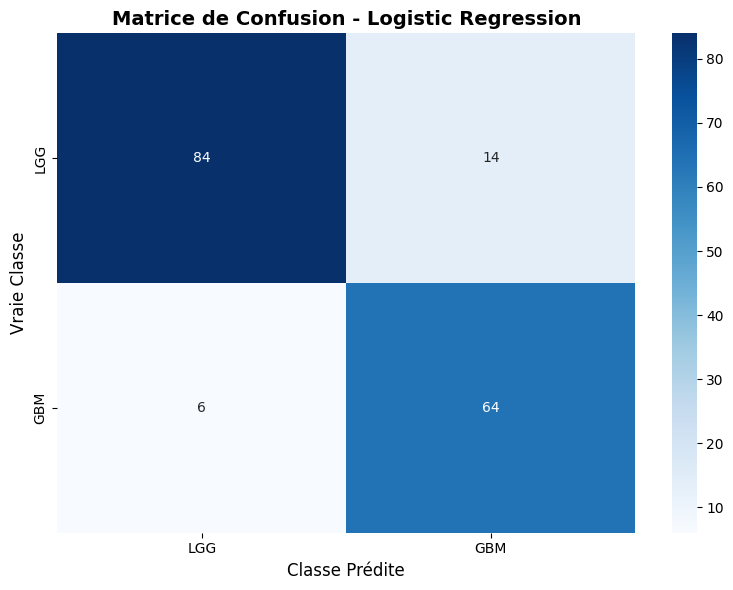


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.93      0.86      0.89        98
         GBM       0.82      0.91      0.86        70

    accuracy                           0.88       168
   macro avg       0.88      0.89      0.88       168
weighted avg       0.89      0.88      0.88       168



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Entraînement du modèle Logistic Regression...")
# Entraînement du modèle Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Évaluation
results_lr = evaluate_model('Logistic Regression', lr,
                            X_train, X_test,
                            y_train, y_test)

In [ ]:
dt = LogisticRegression(random_state=42)
dt.fit(X_train, y_train)

print(f"Accuracy Train: {dt.score(X_train, y_train):.4f}")
print(f"Accuracy Test:  {dt.score(X_test, y_test):.4f}")

Accuracy Train: 0.8824
Accuracy Test:  0.8810


Entraînement du modèle Decision Tree...

MODÈLE: Decision Tree
Accuracy Train      : 0.8854
Accuracy Test       : 0.8214
Precision           : 0.7500
Recall              : 0.8571
F1-Score            : 0.8000
ROC-AUC             : 0.8716


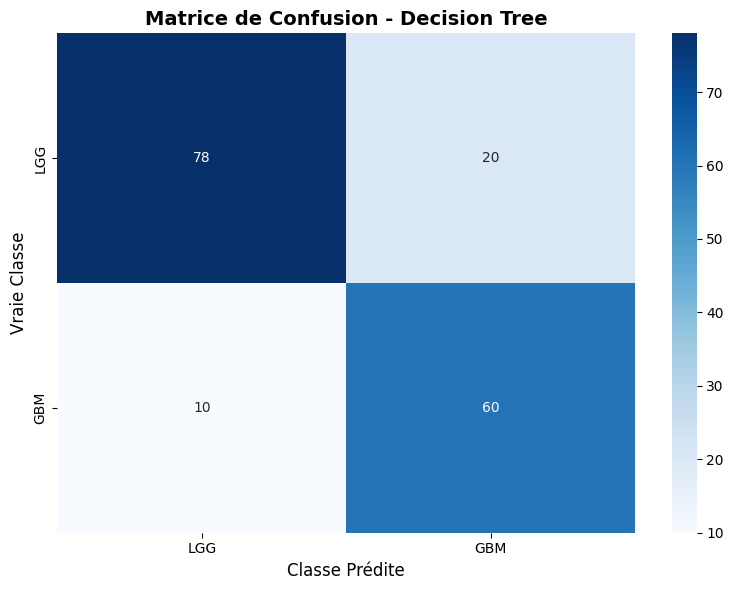


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.89      0.80      0.84        98
         GBM       0.75      0.86      0.80        70

    accuracy                           0.82       168
   macro avg       0.82      0.83      0.82       168
weighted avg       0.83      0.82      0.82       168



In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("Entraînement du modèle Decision Tree...")
# Entraînement du modèle Decision Tree
dt = DecisionTreeClassifier(max_depth=5 ,random_state=42)
dt.fit(X_train, y_train)

# Évaluation
results_dt = evaluate_model('Decision Tree', dt,
                           X_train, X_test,
                           y_train, y_test)

Entraînement du modèle K-Nearest Neighbors...

MODÈLE: K-Nearest Neighbors
Accuracy Train      : 0.8914
Accuracy Test       : 0.8333
Precision           : 0.7692
Recall              : 0.8571
F1-Score            : 0.8108
ROC-AUC             : 0.8937


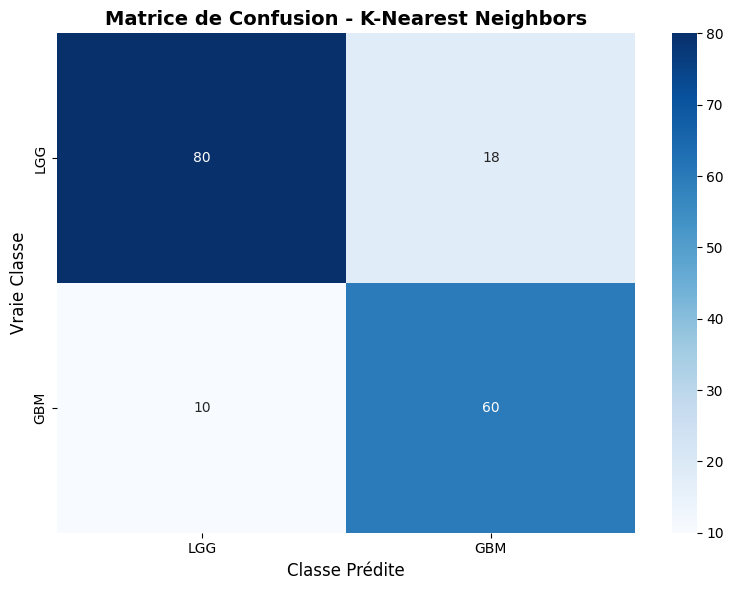


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.89      0.82      0.85        98
         GBM       0.77      0.86      0.81        70

    accuracy                           0.83       168
   macro avg       0.83      0.84      0.83       168
weighted avg       0.84      0.83      0.83       168



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("Entraînement du modèle K-Nearest Neighbors...")
# Entraînement du modèle KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Évaluation
results_knn = evaluate_model('K-Nearest Neighbors', knn,
                             X_train, X_test,
                             y_train, y_test)

Entraînement du modèle Random Forest...

MODÈLE: Random Forest
Accuracy Train      : 0.8824
Accuracy Test       : 0.8631
Precision           : 0.7901
Recall              : 0.9143
F1-Score            : 0.8477
ROC-AUC             : 0.9312


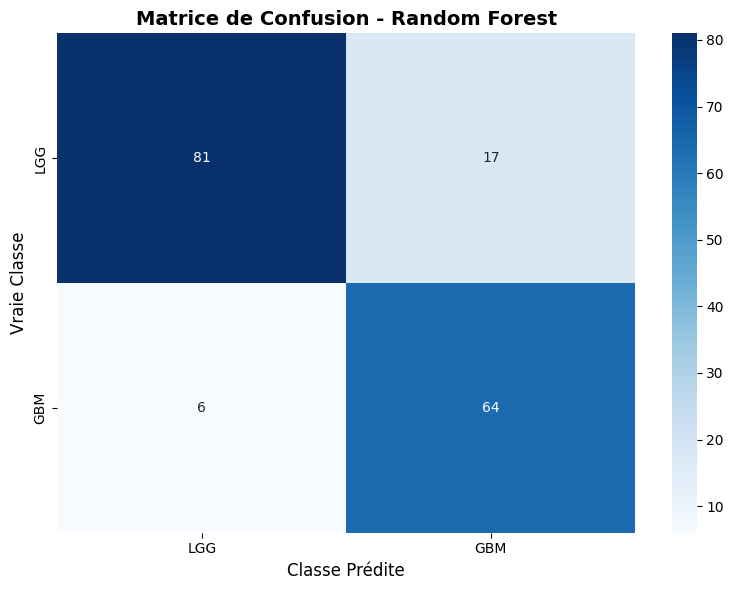


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.93      0.83      0.88        98
         GBM       0.79      0.91      0.85        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168



In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Entraînement du modèle Random Forest...")
# Entraînement du modèle Random Forest
rf = RandomForestClassifier(max_depth=5 ,random_state=42)
rf.fit(X_train, y_train)

# Évaluation
results_rf = evaluate_model('Random Forest', rf,
                           X_train, X_test,
                           y_train, y_test)

Entraînement du modèle XGBoost...

MODÈLE: XGBoost
Accuracy Train      : 0.9598
Accuracy Test       : 0.7976
Precision           : 0.7647
Recall              : 0.7429
F1-Score            : 0.7536
ROC-AUC             : 0.9044


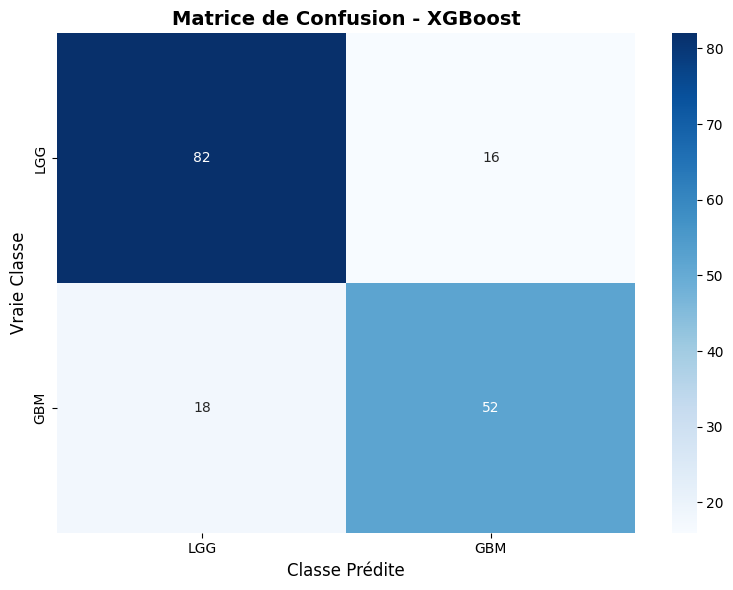


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.82      0.84      0.83        98
         GBM       0.76      0.74      0.75        70

    accuracy                           0.80       168
   macro avg       0.79      0.79      0.79       168
weighted avg       0.80      0.80      0.80       168



In [ ]:
# Entraînement du modèle XGBoost
print("Entraînement du modèle XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Évaluation
results_xgb = evaluate_model('XGBoost', xgb,
                            X_train, X_test,
                            y_train, y_test)


COMPARAISON DES MODÈLES BASELINE
                     Accuracy Train  Accuracy Test  Precision    Recall  F1-Score   ROC-AUC
Modèle                                                                                     
K-Nearest Neighbors        0.891369       0.833333   0.769231  0.857143  0.810811  0.893659
Logistic Regression        0.882440       0.880952   0.820513  0.914286  0.864865  0.916472
Decision Tree              0.885417       0.821429   0.750000  0.857143  0.800000  0.871574
Random Forest              0.882440       0.863095   0.790123  0.914286  0.847682  0.931195
XGBoost                    0.959821       0.797619   0.764706  0.742857  0.753623  0.904373


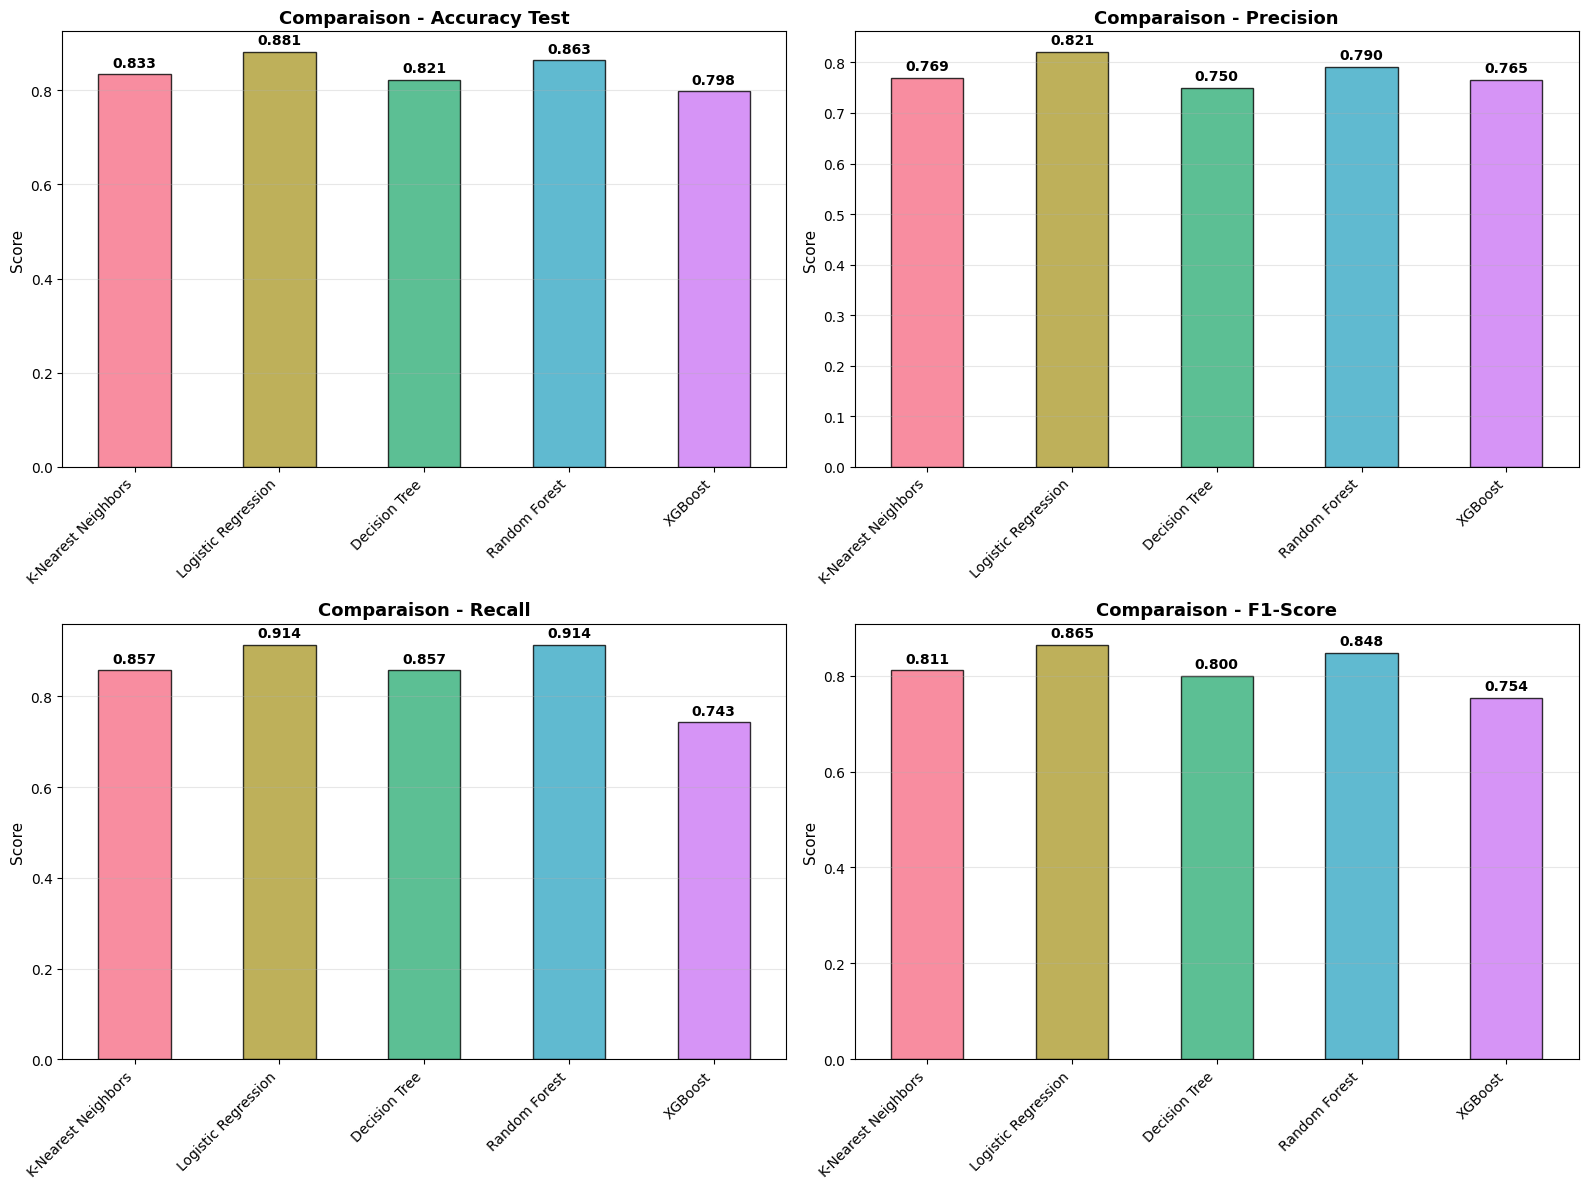

In [ ]:
# Comparaison des résultats
comparison_df = pd.DataFrame([results_knn, results_lr, results_dt, results_rf, results_xgb])
comparison_df = comparison_df.set_index('Modèle')

print("\n" + "="*100)
print("COMPARAISON DES MODÈLES BASELINE")
print("="*100)
print(comparison_df.to_string())

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy Test', 'Precision', 'Recall', 'F1-Score']
colors_palette = sns.color_palette('husl', len(comparison_df))

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2

    comparison_df[metric].plot(kind='bar', ax=axes[row, col],
                               color=colors_palette, alpha=0.8, edgecolor='black')
    axes[row, col].set_title(f'Comparaison - {metric}', fontsize=13, fontweight='bold')
    axes[row, col].set_ylabel('Score', fontsize=11)
    axes[row, col].set_xlabel('')
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=45, ha='right')

    # Ajouter les valeurs sur les barres
    for i, v in enumerate(comparison_df[metric]):
        axes[row, col].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Sélection des 3 meilleurs modèles basés sur le F1-Score
best_models_idx = comparison_df['F1-Score'].nlargest(3).index
print("Top 3 modèles sélectionnés pour le fine-tuning:")
print("="*80)
for i, model_name in enumerate(best_models_idx, 1):
    print(f"{i}. {model_name} - F1-Score: {comparison_df.loc[model_name, 'F1-Score']:.4f}")

Top 3 modèles sélectionnés pour le fine-tuning:
1. Logistic Regression - F1-Score: 0.8649
2. Random Forest - F1-Score: 0.8477
3. K-Nearest Neighbors - F1-Score: 0.8108



FINE-TUNING: Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs paramètres trouvés:
  C: 1
  penalty: l2
  solver: liblinear

Meilleur score (F1) en validation croisée: 0.8675

MODÈLE: Logistic Regression (Tuned)
Accuracy Train      : 0.8824
Accuracy Test       : 0.8810
Precision           : 0.8205
Recall              : 0.9143
F1-Score            : 0.8649
ROC-AUC             : 0.9159


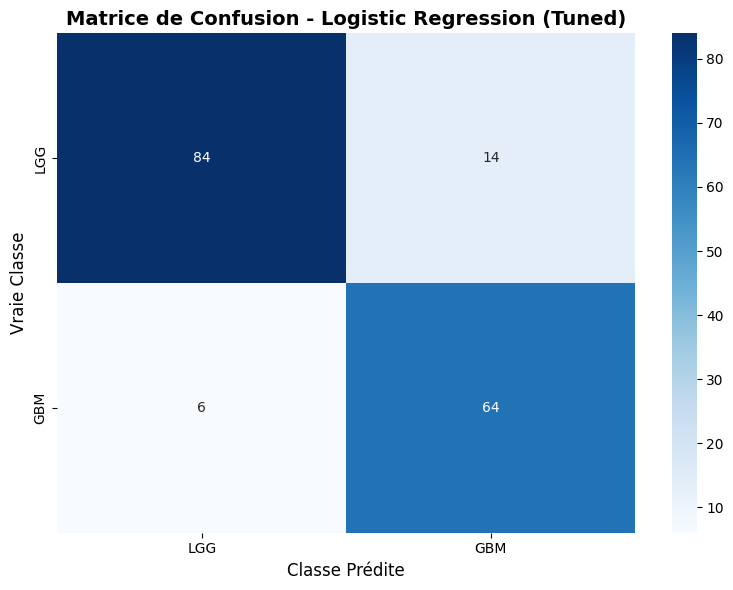


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.93      0.86      0.89        98
         GBM       0.82      0.91      0.86        70

    accuracy                           0.88       168
   macro avg       0.88      0.89      0.88       168
weighted avg       0.89      0.88      0.88       168


FINE-TUNING: Random Forest
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Meilleurs paramètres trouvés:
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Meilleur score (F1) en validation croisée: 0.8641

MODÈLE: Random Forest (Tuned)
Accuracy Train      : 0.8869
Accuracy Test       : 0.8690
Precision           : 0.8000
Recall              : 0.9143
F1-Score            : 0.8533
ROC-AUC             : 0.9315


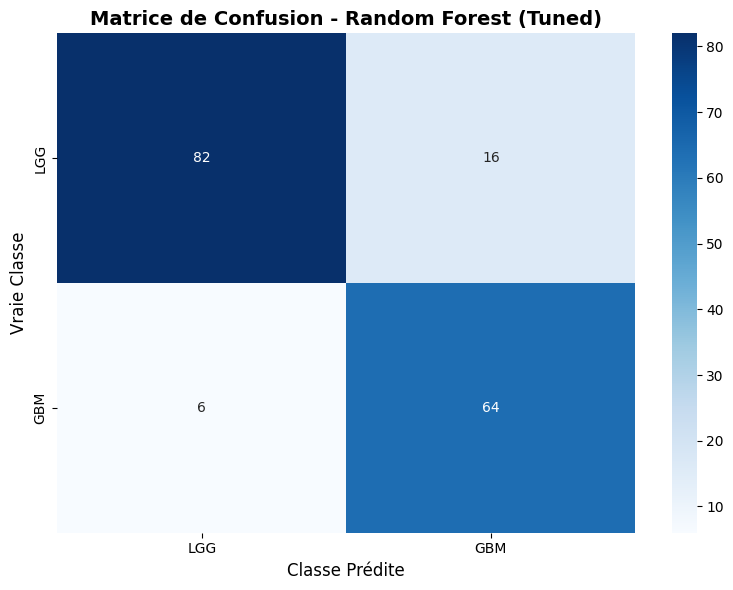


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.93      0.84      0.88        98
         GBM       0.80      0.91      0.85        70

    accuracy                           0.87       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.87      0.87       168


FINE-TUNING: XGBoost
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Meilleurs paramètres trouvés:
  colsample_bytree: 0.6
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 200
  subsample: 0.8

Meilleur score (F1) en validation croisée: 0.8632

MODÈLE: XGBoost (Tuned)
Accuracy Train      : 0.8780
Accuracy Test       : 0.8571
Precision           : 0.7805
Recall              : 0.9143
F1-Score            : 0.8421
ROC-AUC             : 0.9270


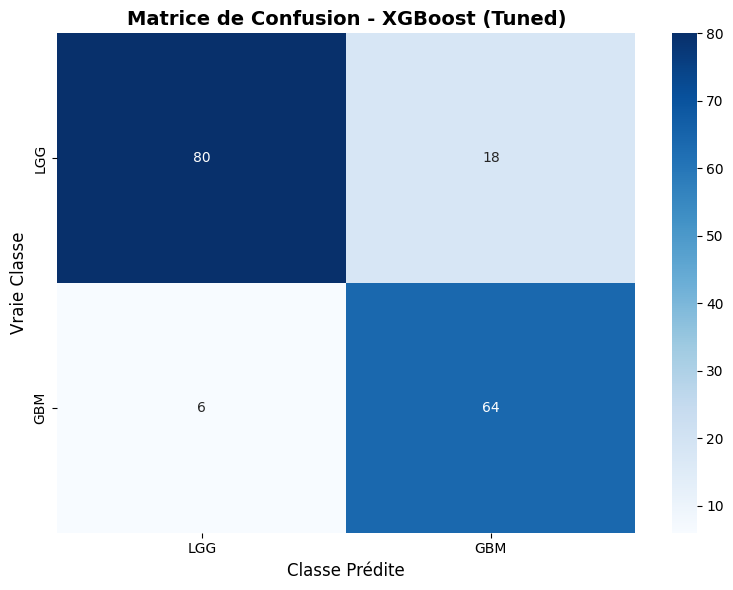


Rapport de classification:
              precision    recall  f1-score   support

         LGG       0.93      0.82      0.87        98
         GBM       0.78      0.91      0.84        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dictionnaire des modèles et paramètres à tuner
models_to_tune = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0]
        }
    }
}

# Stockage des modèles tunés
tuned_models = {}
tuned_results = []

for model_name, config in models_to_tune.items():
    print(f"\n{'='*80}")
    print(f"FINE-TUNING: {model_name}")
    print(f"{'='*80}")

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"\nMeilleurs paramètres trouvés:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nMeilleur score (F1) en validation croisée: {grid_search.best_score_:.4f}")

    # Stocker le meilleur modèle
    tuned_models[model_name] = grid_search.best_estimator_

    # Évaluation sur le test set
    results = evaluate_model(f'{model_name} (Tuned)',
                            grid_search.best_estimator_,
                            X_train, X_test,
                            y_train, y_test)
    tuned_results.append(results)